In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

for _path in (Path.cwd(), *Path.cwd().parents):
    if (_path / "pyproject.toml").is_file():
        _root = str(_path)
        if _root not in sys.path:
            sys.path.insert(0, _root)
        break
else:
    raise RuntimeError("Could not find project root (pyproject.toml)")

import numpy as np
import torch
from weak_sm_cell import WeakSMCell
from cell_evolutions.paths import ROOT, CKPT_DIR, PLOTS_DIR
from cell_evolutions.cell_evolution_model import build_rae, train_rae
from cell_evolutions.cell_evolution_analysis import (
    select_active_cells,
    fit_gaussian_sums,
    mean_r2_by_n_gaussians,
    mean_r2_by_n_and_maxfev,
    print_gaussian_fit_summary,
    select_cells_sensitive_to_n,
)
from cell_evolutions.cell_evolution_plots import (
    plot_ratemap_evolution,
    plot_gaussian_fits,
    plot_mean_r2_vs_n_gaussians,
    plot_mean_r2_by_n_and_maxfev,
    plot_wall_time_by_n_and_maxfev,
    plot_cells_sensitive_to_n,
)


# Load trajectory and arena map

In [2]:
ARENA_NAME = '100x100_square'
explore_speed = 'fast'  # 'fast', 'med', 'slow'
boundary_avoidance = False  # True, False

load_dir = ROOT / 'trajectories' / ARENA_NAME
traj_name = f'traj_{explore_speed}' if not boundary_avoidance else f'traj_{explore_speed}_ba'
arena_map = np.load(load_dir / 'arena_map.npz')['arena_map']
traj_coord = np.load(load_dir / f'{traj_name}.npz')['coord']


# Initialize WeakSMCell and RAE

In [3]:
N_CELLS = 200
WSM_SIGMA = 12
WSM_SSIGMA = 0
WSM_MAGNITUDE = 4
N_HIDDEN = 1024
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

wsm = WeakSMCell(
    arena_map=arena_map,
    n_cells=N_CELLS,
    sigma=WSM_SIGMA,
    ssigma=WSM_SSIGMA,
    magnitude=WSM_MAGNITUDE,
    seed=42,
)

rae = build_rae(N_CELLS, N_HIDDEN, DEVICE)

# Training hyperparameters and helpers

In [4]:
CKPT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MASK_RATE = 0.50
LEARNING_RATE = 0.005
N_EPOCHS = 10
STEP_SIZE = 20
LAMBDA_MSE = 1
LAMBDA_FR = 100


# Train RAE and log rate maps at end of each epoch

In [5]:
traj_coord = traj_coord.reshape(128, 4, -1, 2)
traj_coord = traj_coord.reshape(512, -1, 2)

epoch_ratemaps = train_rae(
    rae,
    traj_coord,
    wsm,
    arena_map,
    DEVICE,
    mask_rate=MASK_RATE,
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    step_size=STEP_SIZE,
    lambda_mse=LAMBDA_MSE,
    lambda_fr=LAMBDA_FR,
    ckpt_dir=CKPT_DIR,
)

Rate map:   0%|          | 0/500 [00:00<?, ?it/s]

Loaded /home/garvalov/thesis/plateau_optimizer/place_cells_episodic_rnn/cell_evolutions/ckpts/latest.pth. Skipping training.


# Evolution plot: one row per cell, one column per epoch

In [6]:
MAX_ACTIVATION_THRESHOLD = 0.2
MAX_CELLS_TO_PLOT = 50
IM_WIDTH = 2

final_rm = epoch_ratemaps[-1]
cell_indices, peak = select_active_cells(
    final_rm,
    threshold=MAX_ACTIVATION_THRESHOLD,
    max_cells=MAX_CELLS_TO_PLOT,
)

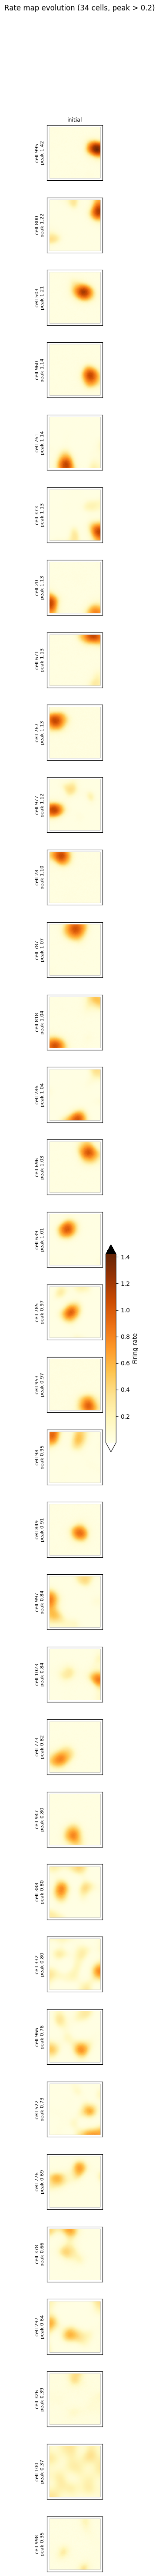

In [7]:
plot_ratemap_evolution(
    epoch_ratemaps,
    cell_indices,
    peak,
    threshold=MAX_ACTIVATION_THRESHOLD,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)

# Gaussian-sum fits

In [8]:
N_GAUSSIANS = 2

gaussian_fits = fit_gaussian_sums(final_rm, cell_indices, n_gaussians=N_GAUSSIANS)
print_gaussian_fit_summary(gaussian_fits, N_GAUSSIANS)

Gaussian fits (N=2, cpu):   0%|          | 0/34 [00:00<?, ?it/s]

Gaussian sum fits (N=2, final epoch):
  cell       R²          AIC
   995    0.990     -76048.1
       g1: amp=1.451 μ=(97.9,47.1) σ=(12.5,10.3)
       g2: amp=0.025 μ=(0.0,77.5) σ=(90.8,110.0)
   800    0.942     -61200.0
       g1: amp=1.234 μ=(101.5,25.8) σ=(10.2,14.1)
       g2: amp=0.384 μ=(8.5,81.0) σ=(11.3,8.4)
   503    0.983     -70821.2
       g1: amp=1.236 μ=(71.7,43.7) σ=(13.1,10.9)
       g2: amp=0.029 μ=(38.2,0.0) σ=(36.3,110.0)
   960    0.986     -73935.3
       g1: amp=1.161 μ=(86.3,67.8) σ=(11.5,13.1)
       g2: amp=0.028 μ=(17.5,0.0) σ=(38.2,110.0)
   761    0.987     -76580.3
       g1: amp=1.183 μ=(36.5,100.7) σ=(10.8,15.5)
       g2: amp=0.190 μ=(95.9,109.0) σ=(10.2,19.9)
   373    0.918     -59875.0
       g1: amp=1.061 μ=(101.1,88.0) σ=(9.2,11.8)
       g2: amp=0.111 μ=(109.0,109.0) σ=(52.2,71.1)
    20    0.983     -73984.6
       g1: amp=1.158 μ=(7.3,87.8) σ=(9.5,14.5)
       g2: amp=0.837 μ=(96.7,103.9) σ=(12.6,11.3)
   671    0.985     -76195.2
       g1: am

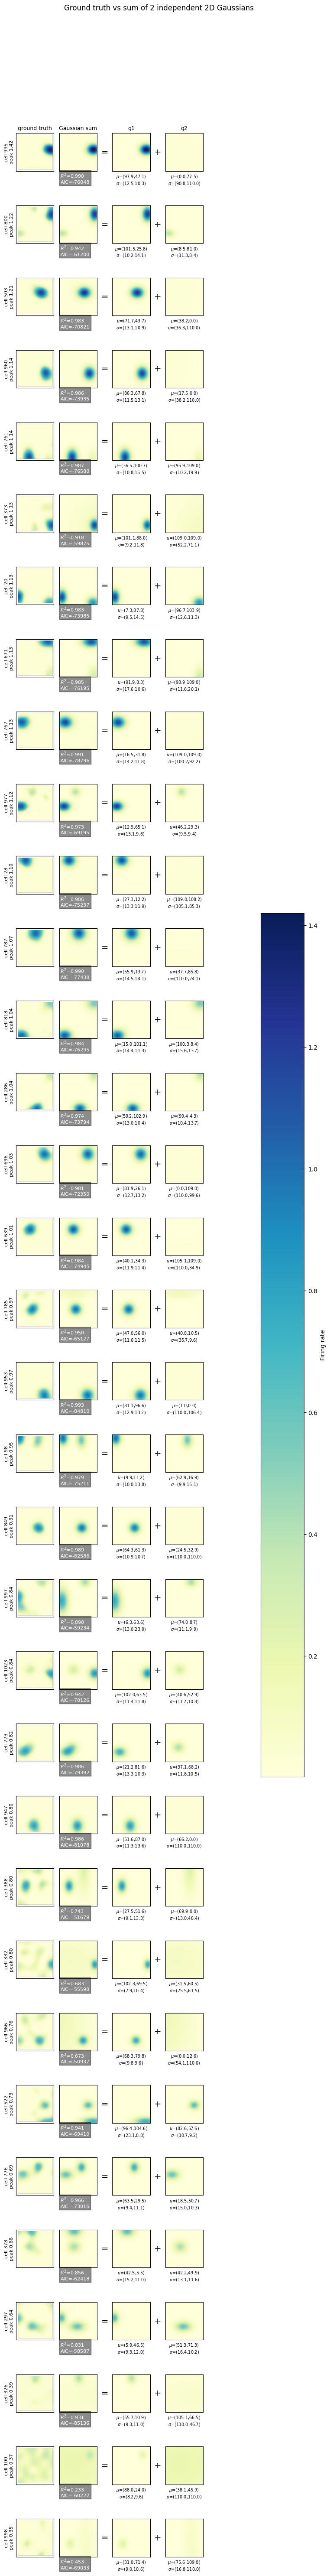

In [9]:
plot_gaussian_fits(
    final_rm,
    gaussian_fits,
    n_gaussians=N_GAUSSIANS,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)

# Mean R² vs number of Gaussians

In [13]:
MAXFEV_VALUES = np.linspace(1,100,10)#np.sort(np.r_[np.logspace(2, 4, 5), 2 * np.logspace(2, 4, 5)]).astype(int)
N_VALUES = [1, 2, 3]

r2_grid = mean_r2_by_n_and_maxfev(
    final_rm,
    cell_indices,
    n_gaussians_values=N_VALUES,
    maxfev_values=MAXFEV_VALUES,
)


R² grid vs N and maxfev:   0%|          | 0/3 [00:00<?, ?it/s]

maxfev (N=1):   0%|          | 0/10 [00:00<?, ?it/s]

maxfev (N=2):   0%|          | 0/10 [00:00<?, ?it/s]

maxfev (N=3):   0%|          | 0/10 [00:00<?, ?it/s]

Gaussian grid total wall time: 347.4 s


In [16]:
plot_mean_r2_by_n_and_maxfev(r2_grid, n_cells=len(cell_indices),log_scale=False)
plot_wall_time_by_n_and_maxfev(r2_grid, n_cells=len(cell_indices),log_scale=False)

r2_grid


{'n_values': array([1, 2, 3]),
 'maxfev_values': array([  1,  12,  23,  34,  45,  56,  67,  78,  89, 100]),
 'mean_r2': array([[       nan, 0.83898827, 0.74095439, 0.73140164, 0.73140164,
         0.73140164, 0.73140164, 0.73140164, 0.73140164, 0.73140164],
        [       nan, 0.9731322 , 0.90494052, 0.89918218, 0.89918218,
         0.89918218, 0.90175612, 0.90175612, 0.90175612, 0.90175612],
        [       nan,        nan, 0.922408  , 0.92490408, 0.9264648 ,
         0.92861321, 0.93062101, 0.9338398 , 0.9338398 , 0.9338398 ]]),
 'wall_time_s': array([[ 0.1891518 ,  0.7791251 ,  0.55578351,  1.75610772,  0.60750592,
          0.83543637,  0.59410198,  0.57870735,  0.68076679,  0.96638668],
        [ 0.14234662,  4.43054677,  7.84140418,  7.37493255, 11.28764268,
         11.52034424,  9.36681184,  8.71939916,  7.91035957,  6.98120399],
        [ 0.35075911, 13.28280315, 31.35522322, 27.56906385, 31.00332683,
         31.01444327, 32.24304234, 31.51330566, 31.83339921, 34.10177494]])

In [12]:
assert False

AssertionError: 

In [21]:
N_GAUSSIANS = 5
r2_by_n = mean_r2_by_n_gaussians(final_rm, cell_indices, n_gaussians_range=N_GAUSSIANS,device="cpu")
r2_by_n

Mean R² vs N Gaussians (cpu):   0%|          | 0/5 [00:00<?, ?it/s]

{'n_values': array([0, 1, 2, 3, 4]),
 'mean_r2': array([       nan, 0.73140164, 0.90175612, 0.9338398 , 0.95870724]),
 'gaussian_fits_by_n': {1: [{'components': [array([[1.11623658e-17, 2.02610911e-17, 3.65522486e-17, ...,
             4.92602290e-05, 4.64820015e-05, 4.35931152e-05],
            [1.70205950e-17, 3.08945103e-17, 5.57355878e-17, ...,
             7.51129663e-05, 7.08766704e-05, 6.64716396e-05],
            [2.57195127e-17, 4.66841349e-17, 8.42210371e-17, ...,
             1.13501843e-04, 1.07100453e-04, 1.00444091e-04],
            ...,
            [2.30325953e-20, 4.18070435e-20, 7.54224656e-20, ...,
             1.01644306e-07, 9.59116688e-08, 8.99506967e-08],
            [1.33351916e-20, 2.42050420e-20, 4.36673774e-20, ...,
             5.88490474e-08, 5.55300202e-08, 5.20787936e-08],
            [7.65112255e-21, 1.38877451e-20, 2.50543423e-20, ...,
             3.37648896e-08, 3.18605837e-08, 2.98804279e-08]], shape=(110, 110))],
    'component_params': [{'amplitude'

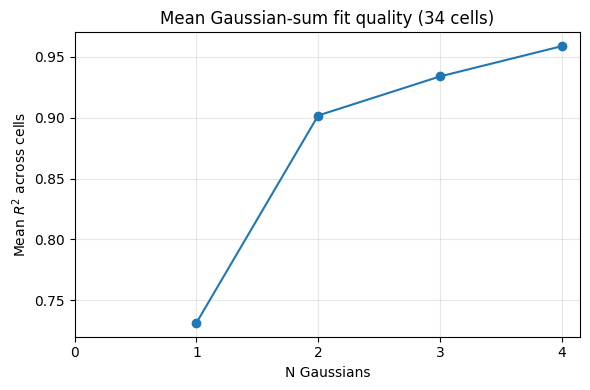

In [22]:
plot_mean_r2_vs_n_gaussians(
    r2_by_n, n_cells=len(cell_indices), output_dir=PLOTS_DIR
)

In [ ]:
r2_by_n["gaussian_fits_by_n"][4][9]

{'components': [array([[5.06690502e-09, 5.51590719e-09, 5.93314440e-09, ...,
          1.33603542e-34, 4.03298700e-35, 1.20289981e-35],
         [7.76822134e-09, 8.45659979e-09, 9.09627845e-09, ...,
          2.04831525e-34, 6.18309117e-35, 1.84420113e-35],
         [1.18516197e-08, 1.29018471e-08, 1.38777756e-08, ...,
          3.12502080e-34, 9.43325913e-35, 2.81361324e-35],
         ...,
         [3.34016849e-01, 3.63615645e-01, 3.91120455e-01, ...,
          8.80731606e-27, 2.65859653e-27, 7.92966914e-28],
         [3.03540639e-01, 3.30438796e-01, 3.55434024e-01, ...,
          8.00372303e-27, 2.41602210e-27, 7.20615397e-28],
         [2.74500159e-01, 2.98824903e-01, 3.21428776e-01, ...,
          7.23798715e-27, 2.18487532e-27, 6.51672348e-28]], shape=(110, 110)),
  array([[3.92262491e-40, 9.17246456e-40, 2.12648707e-39, ...,
          7.93488681e-22, 7.39718483e-22, 6.83690662e-22],
         [1.00019798e-39, 2.33881157e-39, 5.42215511e-39, ...,
          2.02325176e-21, 1.8861475

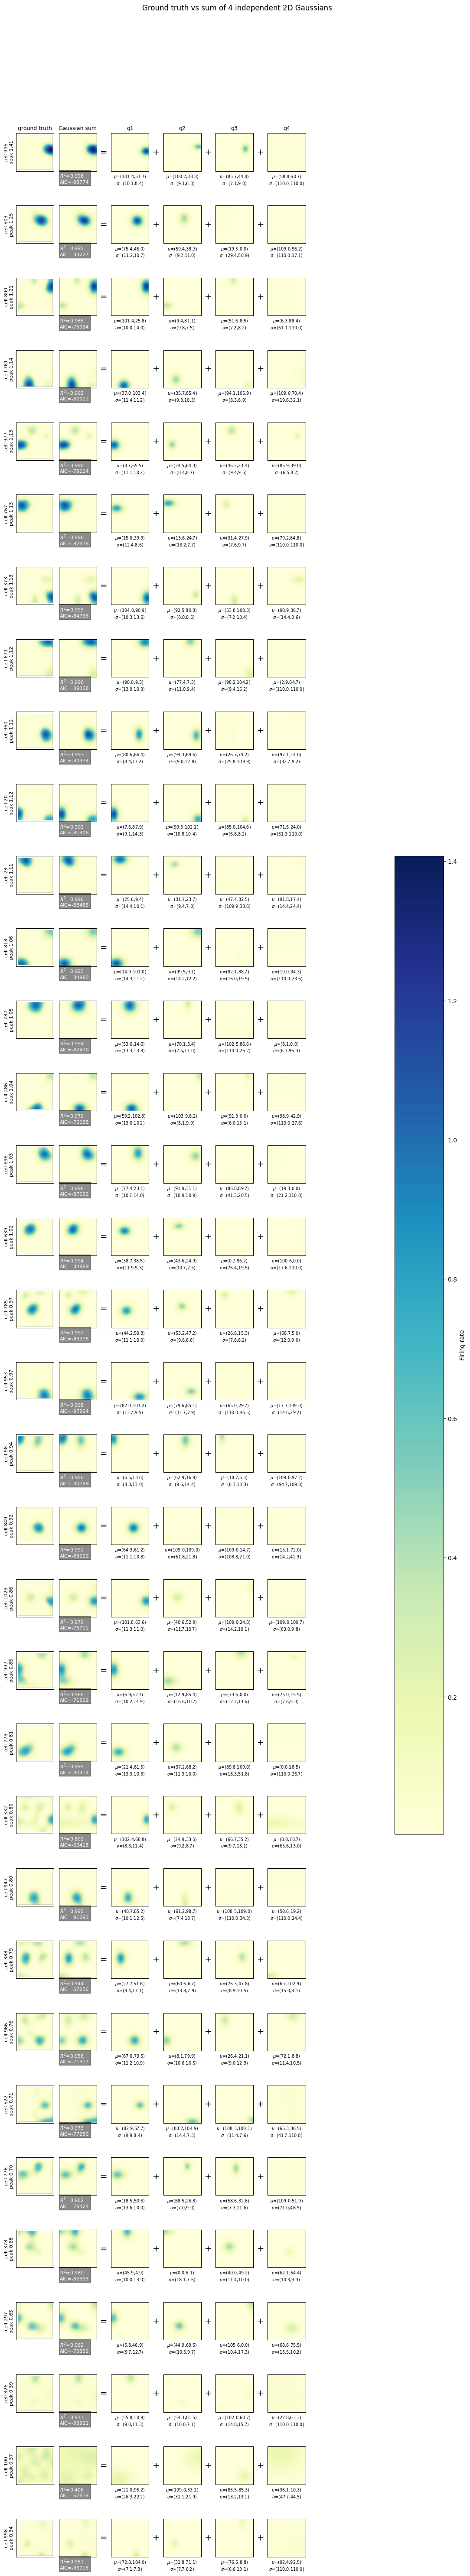

In [ ]:
n_th = N_GAUSSIANS-1
plot_gaussian_fits(
    final_rm,
    r2_by_n["gaussian_fits_by_n"][n_th],
    n_gaussians=n_th,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
)


8 cells with SEM(R²) > 0.1


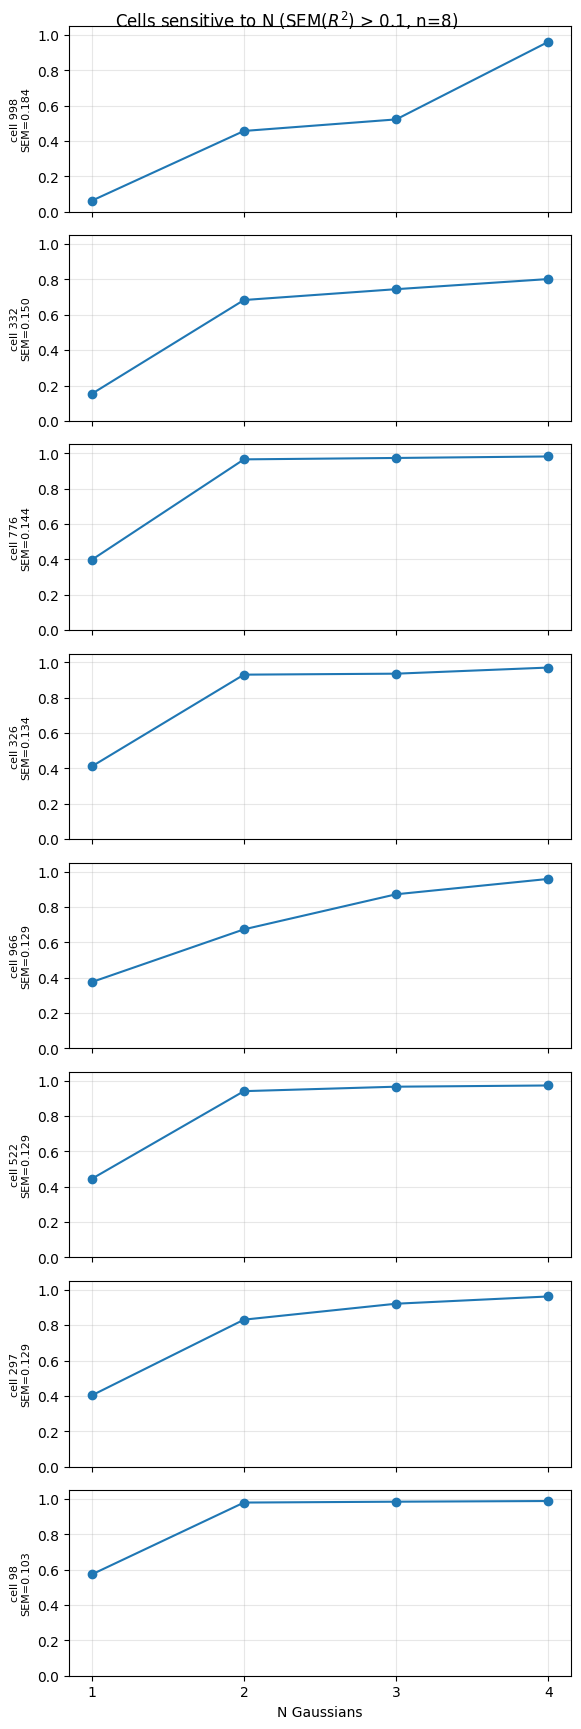

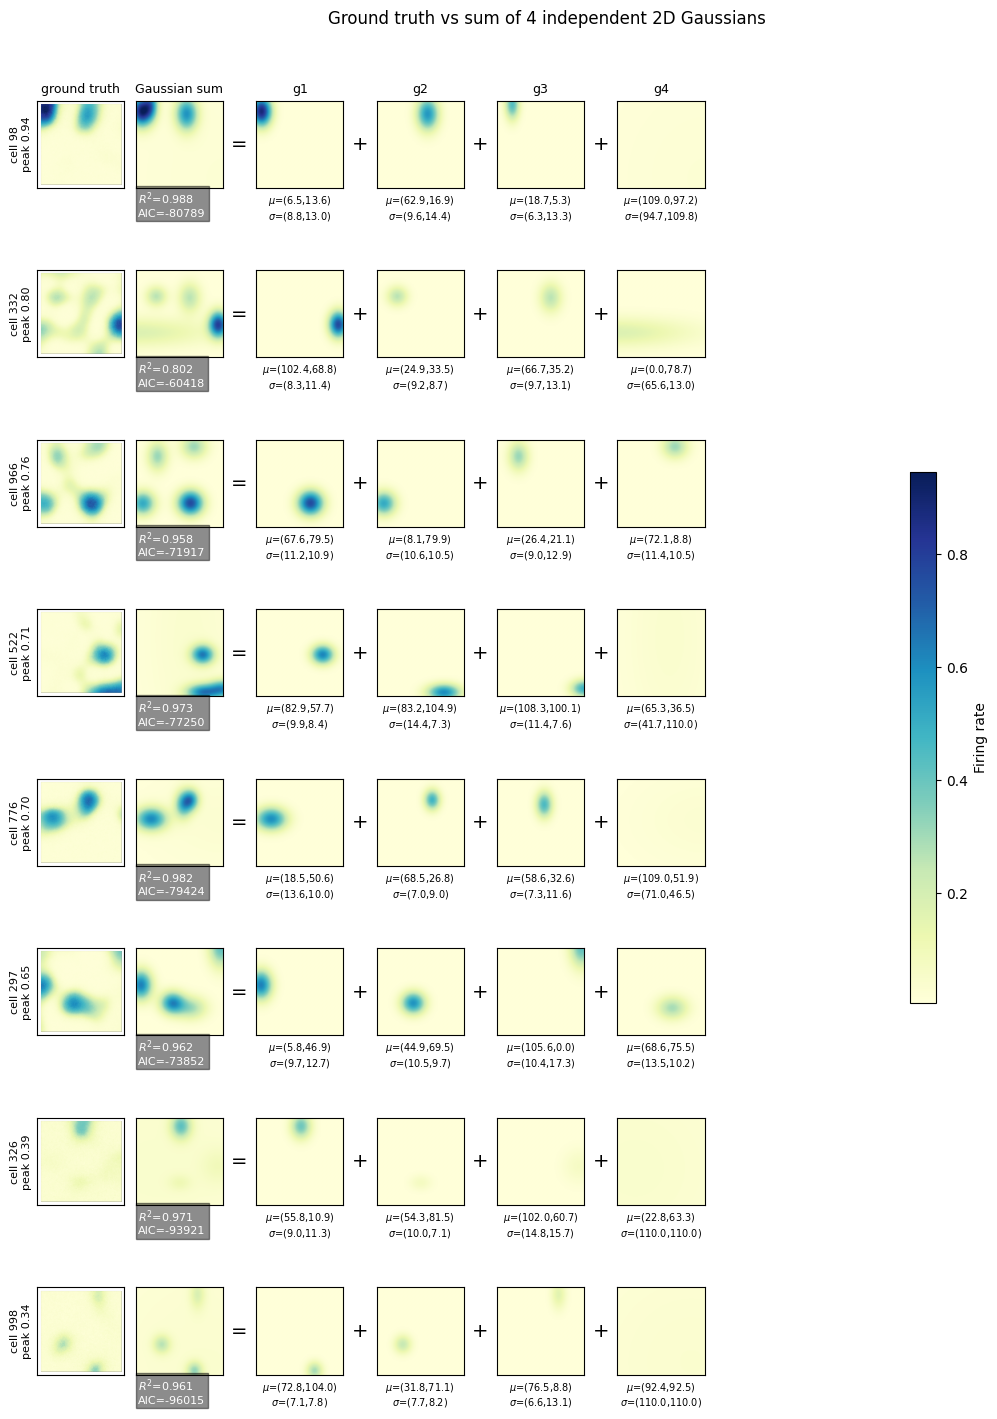

In [ ]:
SEM_THRESHOLD = 0.1

sensitive_cells, sem_by_cell, r2_by_cell, n_values = select_cells_sensitive_to_n(
    r2_by_n,
    sem_threshold=SEM_THRESHOLD,
)
print(f"{len(sensitive_cells)} cells with SEM(R²) > {SEM_THRESHOLD}")

plot_cells_sensitive_to_n(
    r2_by_n,
    sem_threshold=SEM_THRESHOLD,
    output_dir=PLOTS_DIR,
)

sensitive_set = set(sensitive_cells)
sensitive_fits = [
    fit for fit in r2_by_n["gaussian_fits_by_n"][n_th]
    if fit["cell_idx"] in sensitive_set
]
plot_gaussian_fits(
    final_rm,
    sensitive_fits,
    n_gaussians=n_th,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
    save_name=f"gaussian_fits_n{n_th}_sensitive_to_n.pdf",
)

Gaussian fits (N=7, cpu):   0%|          | 0/8 [00:00<?, ?it/s]

Gaussian sum fits (N=7, final epoch):
  cell       R²          AIC
   998    0.970     -98676.8
       g1: amp=0.211 μ=(33.2,69.3) σ=(6.9,7.3)
       g2: amp=0.158 μ=(76.1,8.6) σ=(6.5,13.5)
       g3: amp=0.072 μ=(26.0,77.5) σ=(6.4,6.4)
       g4: amp=0.300 μ=(72.6,104.2) σ=(7.2,8.1)
       g5: amp=0.024 μ=(17.5,24.6) σ=(110.0,110.0)
       g6: amp=0.020 μ=(92.9,76.3) σ=(11.6,65.0)
       g7: amp=0.017 μ=(38.5,83.5) σ=(23.9,18.0)
   332    0.965     -77958.3
       g1: amp=0.268 μ=(67.6,34.6) σ=(9.3,12.0)
       g2: amp=0.287 μ=(77.2,103.5) σ=(8.4,10.1)
       g3: amp=0.276 μ=(24.9,34.5) σ=(9.3,7.5)
       g4: amp=0.803 μ=(102.8,69.4) σ=(9.3,11.5)
       g5: amp=0.335 μ=(0.0,76.4) σ=(18.3,9.8)
       g6: amp=0.227 μ=(28.0,0.1) σ=(15.4,8.6)
       g7: amp=0.190 μ=(53.6,72.9) σ=(8.7,13.7)
   776    0.994     -90994.0
       g1: amp=0.682 μ=(64.5,26.6) σ=(9.0,8.8)
       g2: amp=0.562 μ=(19.5,47.5) σ=(13.5,7.7)
       g3: amp=0.286 μ=(58.9,41.2) σ=(8.1,7.3)
       g4: amp=0.019 μ=(43.3,85

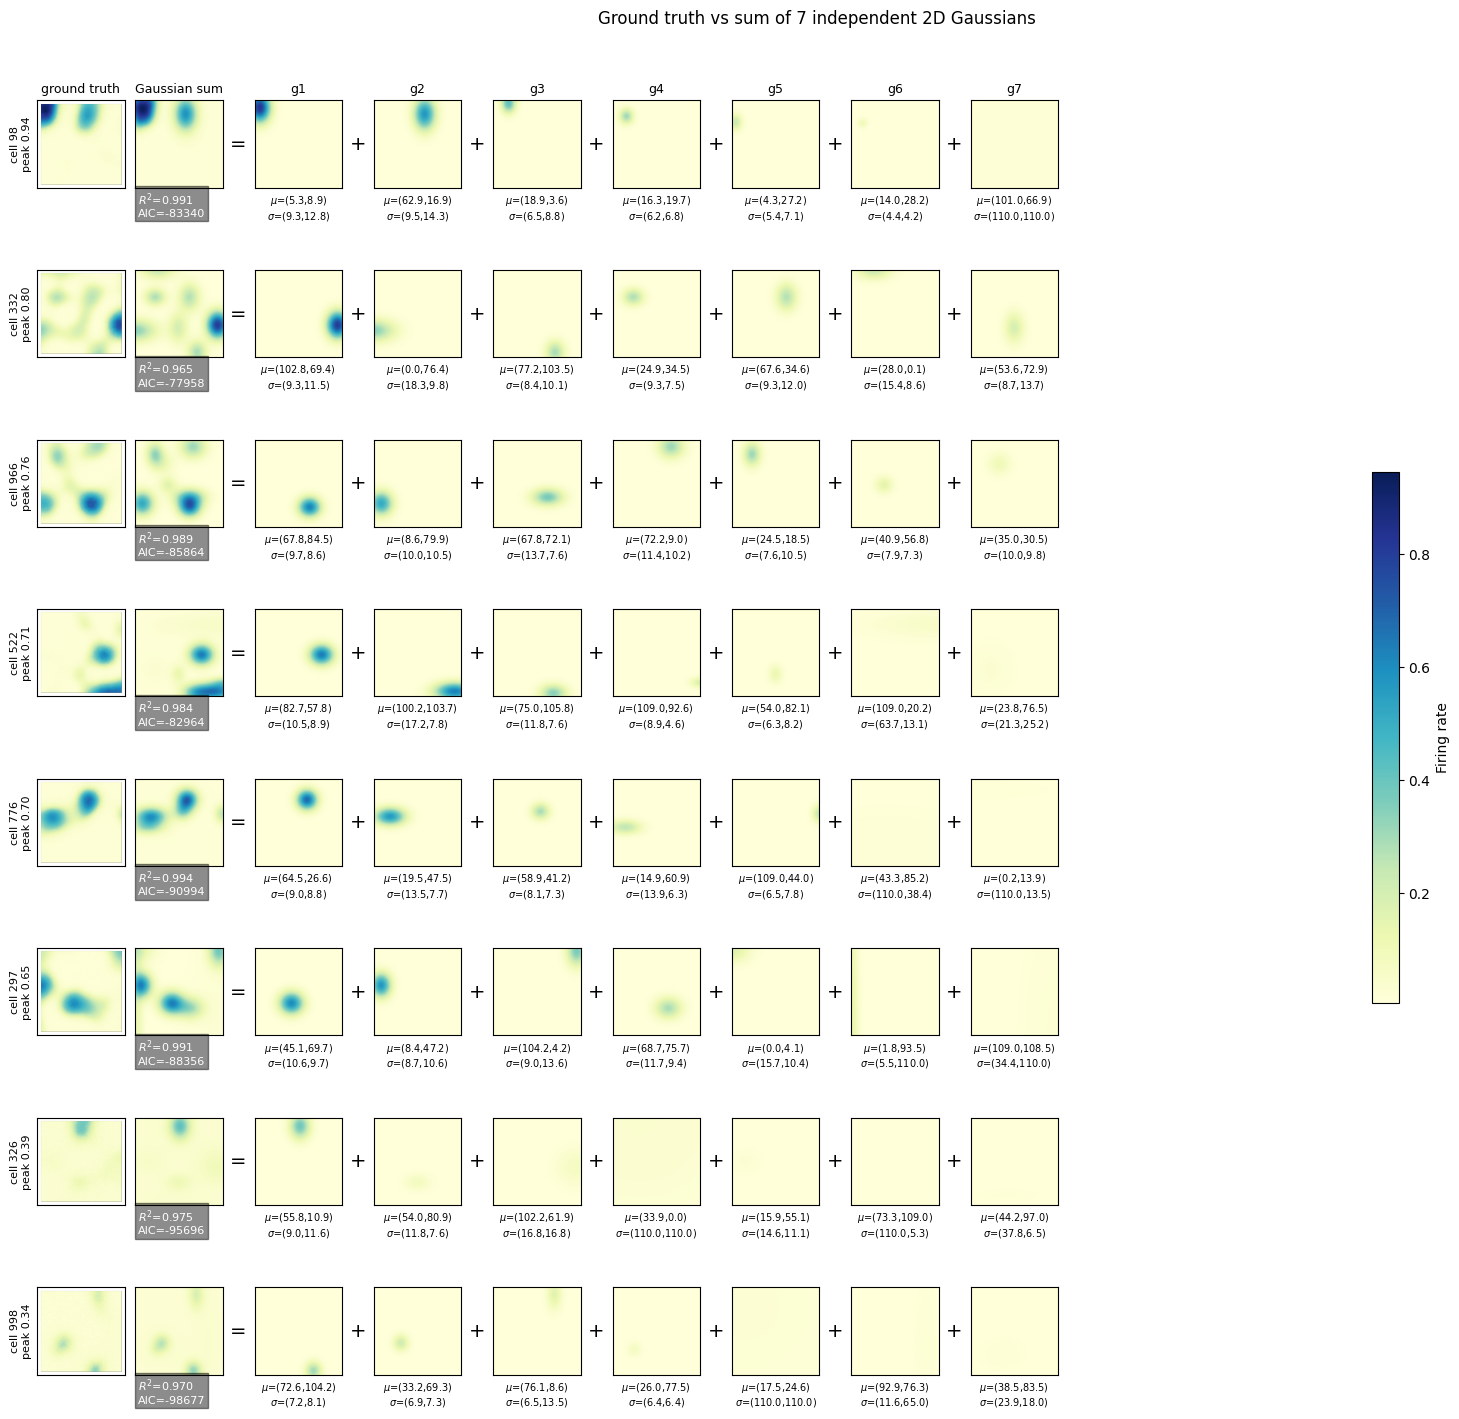

In [ ]:
# Fit N=7 only for cells already selected as sensitive to N (no 1..7 sweep)
N_FURTHER_GAUSSIANS = 7

further_fits = fit_gaussian_sums(
    final_rm,
    sensitive_cells,
    n_gaussians=N_FURTHER_GAUSSIANS,
    device="cpu",
)
print_gaussian_fit_summary(further_fits, N_FURTHER_GAUSSIANS)

plot_gaussian_fits(
    final_rm,
    further_fits,
    n_gaussians=N_FURTHER_GAUSSIANS,
    im_width=IM_WIDTH,
    output_dir=PLOTS_DIR,
    save_name=f"gaussian_fits_n{N_FURTHER_GAUSSIANS}_sensitive_to_n.pdf",
)
